In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/processed_data_v1.csv')
print('Dataset loaded successfully.')
print('shape of the dataset:', df.shape)
df.head()

Dataset loaded successfully.
shape of the dataset: (17880, 12)


,telecommuting,has_company_logo,has_questions,fraudulent,job_description,jd_word_count,req_exp_enc,employment_type_Full-time,employment_type_Other,employment_type_Part-time,employment_type_Temporary,employment_type_Unknown
0,0,1,0,0,NaN,0,6.0,False,True,False,False,False
1,0,1,0,0,Customer Service - Cloud Video Production 90 S...,901,6.0,True,False,False,False,False
2,0,1,0,0,NaN,0,6.0,False,False,False,False,True
3,0,1,0,0,Account Executive - Washington DC Our passion ...,709,3.0,True,False,False,False,False
4,0,1,1,0,Bill Review Manager SpotSource Solutions LLC i...,470,3.0,True,False,False,False,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   telecommuting              17880 non-null  int64  
 1   has_company_logo           17880 non-null  int64  
 2   has_questions              17880 non-null  int64  
 3   fraudulent                 17880 non-null  int64  
 4   job_description            8845 non-null   object 
 5   jd_word_count              17880 non-null  int64  
 6   req_exp_enc                17880 non-null  float64
 7   employment_type_Full-time  17880 non-null  bool   
 8   employment_type_Other      17880 non-null  bool   
 9   employment_type_Part-time  17880 non-null  bool   
 10  employment_type_Temporary  17880 non-null  bool   
 11  employment_type_Unknown    17880 non-null  bool   
dtypes: bool(5), float64(1), int64(5), object(1)
memory usage: 1.0+ MB


In [4]:
# Handling missing values in 'job_description' column
df['job_description'] = df['job_description'].fillna("")
print('Missing values in job_description filled with empty strings.')

Missing values in job_description filled with empty strings.


In [5]:
# just checking it
df.job_description.isna().sum()

np.int64(0)

Separate Features & Target

In [7]:
text_cols = 'job_description'

numeric_cols = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'jd_word_count',
    'req_exp_enc',
    'employment_type_Full-time',
    'employment_type_Other',
    'employment_type_Part-time',
    'employment_type_Temporary',
    'employment_type_Unknown'
]

print('Features are saperated.')

Features are saperated.


Required imports

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

Adding version to avoid version conflict in deployment.

In [9]:
import sklearn
import pandas
import numpy
import xgboost
print(sklearn.__version__)
print(pandas.__version__)
print(numpy.__version__)
print(xgboost.__version__)

1.7.1
2.3.1
2.2.6
3.1.2


Building preprocessor

In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ('job_description', TfidfVectorizer(
            max_features=20000,
            ngram_range=(1,2),
            min_df=5,
            stop_words='english',
        ), text_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)
print('Preprocessing is done')

Preprocessing is done


Now split and train

In [78]:
X = df[[text_cols] + numeric_cols]
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Data is splited')

Data is splited


In [80]:
# just little sanity check
print(X_train.shape)
print(X_test.shape)

print('okay, Looks good.')

(14304, 11)
(3576, 11)
okay, Looks good.


In [79]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 19.64069264069264


After addressing class imbalance using scale_pos_weight, the model achieved very high fraud recall.

I then tuned the decision threshold and selected 0.8, which provided the best trade-off between fraud recall and precision, maximizing the fraud F1-score while keeping false positives manageable.

You will see this by executing next cells.

Buils XGBoost model

In [104]:
xgboost_model = XGBClassifier(
    n_estimators = 300,
    max_depth = 6,
    learning_rate = 0.1,
    eval_metric = 'logloss',
    scale_pos_weight = scale_pos_weight,
)
print('XGBoost model is ready for pipeline.')

XGBoost model is ready for pipeline.


Building a pipline

In [83]:
xgboost_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('xgboost_model', xgboost_model)
        # ('xgboost_model', XGBClassifier(
        #     n_estimators = 300,
        #     max_depth = 6,
        #     learning_rate = 0.1,
        #     eval_metric = 'logloss',
        #     # scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        # ))
    ]
)
print('XGBoost Pipeline is created')

XGBoost Pipeline is created


model training

In [84]:
xgboost_pipeline.fit(X_train, y_train)
print('Model training is completed.')

Model training is completed.


Now Evalution for this XGBoost model

In [85]:
# predictions
y_pred = xgboost_pipeline.predict(X_test)
y_prob = xgboost_pipeline.predict_proba(X_test)[:, 1]

# classification report
from sklearn.metrics import classification_report

print('XGBoost classification report: ')
report = classification_report(y_test, y_pred, digits=4)
print(report)

XGBoost classification report: 
              precision    recall  f1-score   support

           0     0.9911    0.8828    0.9338      3403
           1     0.2679    0.8439    0.4067       173

    accuracy                         0.8809      3576
   macro avg     0.6295    0.8633    0.6702      3576
weighted avg     0.9561    0.8809    0.9083      3576



Confusion metrix for XGBoost


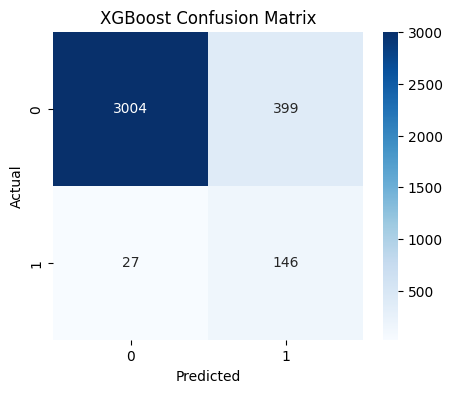

In [86]:
print('Confusion metrix for XGBoost')
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [87]:
from sklearn.metrics import roc_auc_score

roc_auc_xgb = roc_auc_score(y_test, y_prob)
print("XGBoost ROC-AUC:", roc_auc_xgb)


XGBoost ROC-AUC: 0.922861331127414


Going further to improve XGBoost by:

* Threshold tuning 

Trying multiple thresholds:

In [88]:
# tuning
threshold_list = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in threshold_list:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print(f'\nThreshold = {threshold}')
    print(classification_report(y_test, y_pred_threshold, digits=4))


Threshold = 0.3
              precision    recall  f1-score   support

           0     0.9926    0.8287    0.9033      3403
           1     0.2068    0.8786    0.3348       173

    accuracy                         0.8311      3576
   macro avg     0.5997    0.8536    0.6190      3576
weighted avg     0.9546    0.8311    0.8758      3576


Threshold = 0.4
              precision    recall  f1-score   support

           0     0.9927    0.8346    0.9068      3403
           1     0.2126    0.8786    0.3423       173

    accuracy                         0.8367      3576
   macro avg     0.6026    0.8566    0.6246      3576
weighted avg     0.9549    0.8367    0.8795      3576


Threshold = 0.5
              precision    recall  f1-score   support

           0     0.9911    0.8828    0.9338      3403
           1     0.2679    0.8439    0.4067       173

    accuracy                         0.8809      3576
   macro avg     0.6295    0.8633    0.6702      3576
weighted avg     0.9561

Precision-Recall curve

Average pricision:  0.5355487534246002


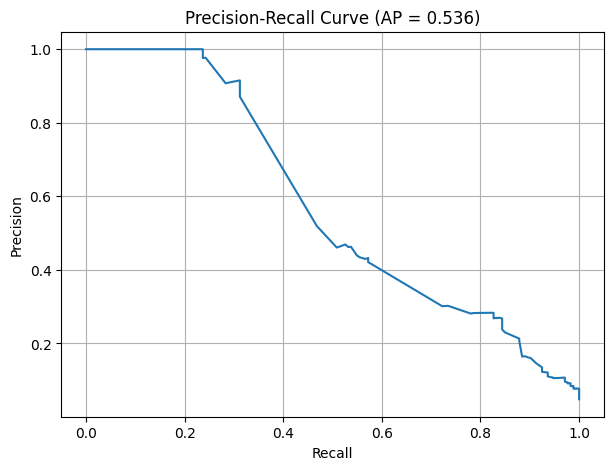

In [89]:
from sklearn.metrics import average_precision_score, precision_recall_curve

precision, recall, threshold_list =  precision_recall_curve(y_test, y_prob)

avg_precision = average_precision_score(y_test, y_prob)
print('Average pricision: ', avg_precision)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {avg_precision:.3f})")
plt.grid(True)
plt.show()


The Precision–Recall curve shows a clear elbow around recall ≈ 0.57, where precision is still ≈ 0.5. I selected a threshold of 0.8 to operate in this region.

Choosing threshold from PR curve

In [101]:
target_recall = 0.57

idx = np.where(recall[:-1] >= target_recall)[0][-1]
FINAL_THRESHOLD = threshold_list[idx]

print("Chosen threshold:", FINAL_THRESHOLD)
print("Precision at this point:", precision[idx])
print("Recall at this point:", recall[idx])


Chosen threshold: 0.8223218
Precision at this point: 0.43231441048034935
Recall at this point: 0.5722543352601156


Confusion Matrix at Best Threshold

If i considering *Law enforcement / Scam investigation* that's why i seleced 0.8

Confusion Metrix after threshold tuning: 


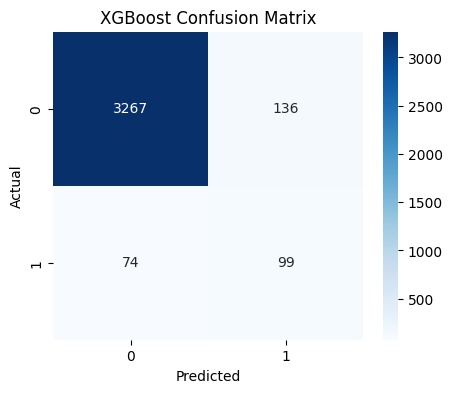

In [91]:
print('Confusion Metrix after threshold tuning: ')
FINAL_THRESHOLD = 0.8  # Final decision threshold selected after tuning

y_final_pred = (y_prob >= FINAL_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_final_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

Initially, threshold tuning alone improved recall, but after incorporating class weighting, the model became aggressive. 

I then increased the threshold to 0.8 to control false positives, which resulted in the best fraud F1-score.

Feature Importance:

Extract feature importance, this answers Why did the model flag a job as fraud?

In [107]:
# Get the trained XGBoost model
xgb_model = xgboost_pipeline.named_steps['xgboost_model']

# Get feature importances
importance = xgb_model.feature_importances_

# Get feature names from the ColumnTransformer
preprocessor = xgboost_pipeline.named_steps['preprocessor']

tfidf = preprocessor.named_transformers_['job_description']  # tf-idf feature names
tfidf_features = tfidf.get_feature_names_out()

numeric_features = numeric_cols

all_feature_names = list(tfidf_features) + numeric_features # combined all fearures

# Create feature-importance DataFrame
imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importance
})

imp_df = imp_df.sort_values(by='importance', ascending=False)

print("Top 30 important features:")
imp_df.head(30)

Top 30 important features:


,feature,importance
6989,facilitating,0.046615
13722,process provide,0.039099
5298,diligence,0.035362
11836,new exciting,0.035272
16339,small business,0.033778
6020,encouraged,0.029769
20001,has_company_logo,0.029040
4256,created,0.027510
8973,incoming,0.021797
6416,established,0.021633


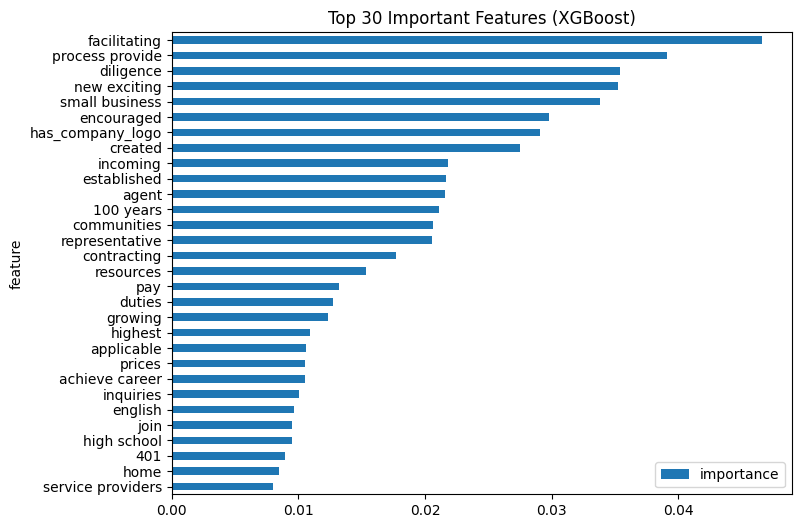

In [108]:
# plot top features
imp_df.head(30).plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,6)
)

plt.gca().invert_yaxis()
plt.title("Top 30 Important Features (XGBoost)")
plt.show()

I extracted global feature importance from the trained XGBoost model to understand which textual and structured features most influenced fraud predictions.

Save (Model, vectorizer, and threshold)

In [109]:
from pathlib import Path
import joblib

# create model directory
MODEL_DIR = Path("../model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# save full pipeline (preprocessing + model)
joblib.dump(
    xgboost_pipeline,
    MODEL_DIR / "fraud_detection_pipeline.pkl"
)

# save final decision threshold
joblib.dump(
    FINAL_THRESHOLD,
    MODEL_DIR / "decision_threshold.pkl"
)

print("Pipeline and threshold saved successfully.")

Pipeline and threshold saved successfully.
